# Bayesian modelling of chocolate quality rating
#### Authors: Julia Wiktorowicz, Patrycja Wybranowska

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from cmdstanpy import CmdStanModel
import arviz as az
import matplotlib
import matplotlib.colors as mcolors

RELATIVE = True


## Data preprocessing
The raw data from Flavors of Cacao database contains information about producer and its origin country, country and details of bean origin, basic ingredients, most memorable characteristics, final rating and date of the review.



In [2]:
columns = [
    'REF', 'Company', 'Company Location', 'Review Date', 
    'Country of Bean Origin', 'Specific Bean Origin', 
    'Cocoa Percent', 'Ingredients', 'Most Memorable Characteristics', 'Rating'
]

df_pre = pd.read_csv('data/data.txt', sep='\t', names=columns, skiprows=1) if RELATIVE else pd.read_csv('/workspace/project2/Chocolate-DA/data/data.txt', sep='\t', names=columns, skiprows=1)
df_pre.head()

,REF,Company,Company Location,Review Date,Country of Bean Origin,Specific Bean Origin,Cocoa Percent,Ingredients,Most Memorable Characteristics,Rating
0,3016,Cacao Store,Japan,2026,Thailand,Chumphon,70%,"3- B,S,C","light apricot, pear, nutty, clean",3.25
1,3016,Cacao Store,Japan,2026,Taiwan,Fu-Wan,70%,"3- B,S,C","cocoa,roasty,pungent, chemical",2.75
2,3016,Cacao Store,Japan,2026,Madagascar,Ambanja,75%,"3- B,S,C","high acid, atypical honey",3.00
3,3016,URA,Peru,2026,Peru,"Piura, Chulucanas, Finca Tito Jimenez",70%,"3- B,S,C","grapes, roast (smoke like)",3.75
4,3020,URA,Peru,2026,Peru,"VRAEM 99, Pichari, Cusco, Finca Daria",70%,"3- B,S,C",plum,3.50


In [4]:
df = pd.read_csv('data/chocolate_data_preprocessed.csv') if RELATIVE else pd.read_csv('/workspace/project2/Chocolate-DA/data/chocolate_data_preprocessed.csv')

observed_ratings = sorted(df['Rating'].unique())     # only values that actually occur
rating_map = {val: i + 1 for i, val in enumerate(observed_ratings)}
inv_rating_map = {v: k for k, v in rating_map.items()}   # build this here, right next to rating_map

df['rating_id'] = df['Rating'].map(rating_map)
C = len(observed_ratings)
J = df['Bean Origin ID'].max()
K = df['Company Location ID'].max()


print(f"C = {C}")
print(df['rating_id'].value_counts().sort_index())
print(f"NaNs in rating_id: {df['rating_id'].isna().sum()}")  # should be 0
df.head()

# for each bean origin, find the most common producer location
origin_to_loc = (
    df.groupby('Bean Origin ID')['Company Location ID']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
# list of length J: for origin j, which producer location is it primarily from
origin_location = [int(origin_to_loc[j]) for j in range(1, J + 1)]

C = 8
rating_id
1      3
2     54
3    113
4    248
5    223
6    276
7    118
8     41
Name: count, dtype: int64
NaNs in rating_id: 0


### Prior predictive check

In [6]:
prior_model1 = CmdStanModel(stan_file="prior_model1.stan") if RELATIVE else CmdStanModel(stan_file="/workspace/project2/Chocolate-DA/prior_model1.stan")

J = df['Bean Origin ID'].max()
K = df['Company Location ID'].max()

prior_data1 = {
    "N": len(df),
    "J": J,
    "K": K,
    "C": C,
    "origin":          df['Bean Origin ID'].tolist(),
    "producer":        df['Company Location ID'].tolist(),
    "origin_location": origin_location,    # ← new, must be computed before this cell
}


prior_fit1 = prior_model1.sample(
    data=prior_data1,
    fixed_param=True,
    iter_sampling=2000,
    chains=1,
    seed=42,
    show_progress=False,
)



# pull everything including the new parameters
rating_pred_prior1   = prior_fit1.stan_variable("rating_pred")
a_prior_draws1       = prior_fit1.stan_variable("alpha")
b_prior_draws1       = prior_fit1.stan_variable("gamma")
mu_global_prior1     = prior_fit1.stan_variable("mu_global")     # ← was missing
sigma_origin_prior1  = prior_fit1.stan_variable("sigma_origin")
sigma_prod_prior1    = prior_fit1.stan_variable("sigma_producer")
sigma_lam_prior1     = prior_fit1.stan_variable("sigma_lambda")  # ← was missing
alpha_prior1         = prior_fit1.stan_variable("alpha")
gamma_prior1         = prior_fit1.stan_variable("gamma")         # ← was missing
c_prior_draws        = prior_fit1.stan_variable("c")

09:25:30 - cmdstanpy - INFO - CmdStan start processing
09:25:30 - cmdstanpy - INFO - Chain [1] start processing
09:25:32 - cmdstanpy - INFO - Chain [1] done processing


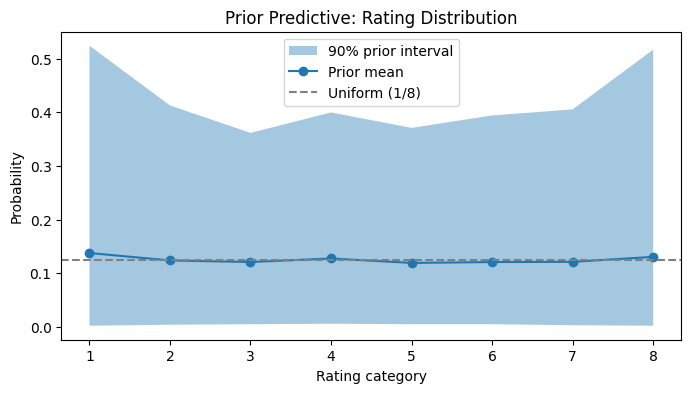

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
# rating_pred shape: (n_draws, N) — average over observations
pred_counts = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_prior1
)
pred_probs = pred_counts / pred_counts.sum(axis=1, keepdims=True)

ax.fill_between(
    range(1, C+1),
    np.percentile(pred_probs, 5, axis=0),
    np.percentile(pred_probs, 95, axis=0),
    alpha=0.4, label="90% prior interval"
)
ax.plot(range(1, C+1), pred_probs.mean(axis=0), marker='o', label="Prior mean")
ax.axhline(1/C, ls='--', color='gray', label=f"Uniform (1/{C})")
ax.set_xlabel("Rating category"); ax.set_ylabel("Probability")
ax.set_title("Prior Predictive: Rating Distribution")
ax.legend()

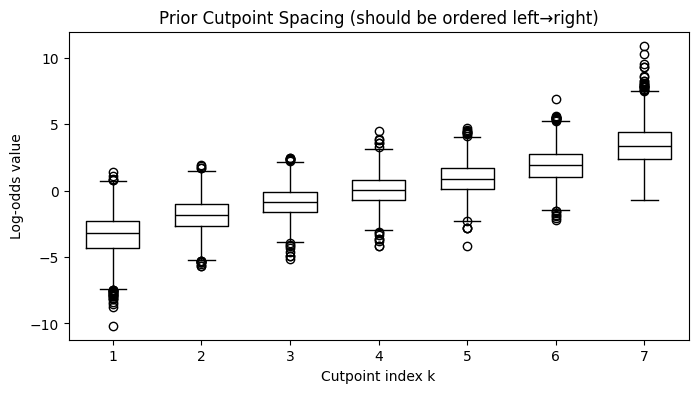

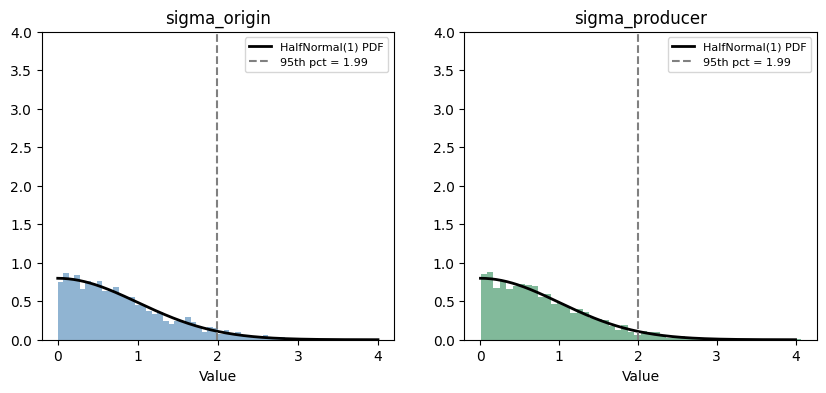

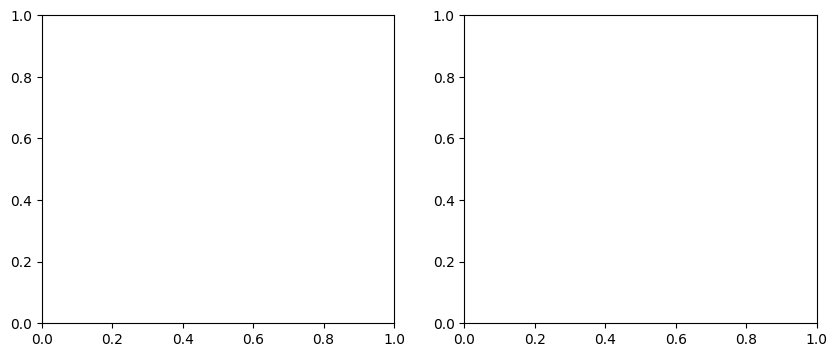

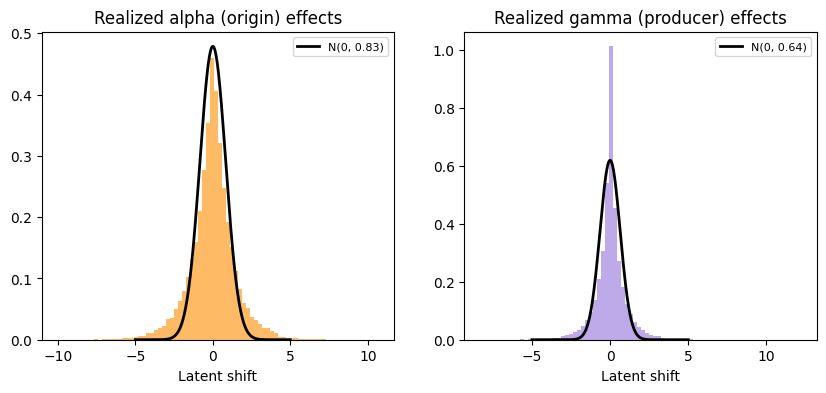

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
for k in range(C - 1):
    ax.boxplot(c_prior_draws[:, k], positions=[k+1], widths=0.6,
               medianprops=dict(color='black'))
ax.set_xlabel("Cutpoint index k")
ax.set_ylabel("Log-odds value")
ax.set_title("Prior Cutpoint Spacing (should be ordered left→right)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.linspace(0, 4, 300)
ref = stats.halfnorm.pdf(x, scale=1.0)

for ax, samples, name, color in zip(
    axes,
    [sigma_origin_prior1, sigma_prod_prior1],
    ["sigma_origin", "sigma_producer"],
    ["steelblue", "seagreen"]
):
    ax.hist(samples, bins=50, density=True, alpha=0.6, color=color)
    ax.plot(x, ref, 'k-', lw=2, label="HalfNormal(1) PDF")
    ax.axvline(np.percentile(samples, 95), ls='--', color='gray',
               label=f"95th pct = {np.percentile(samples,95):.2f}")
    ax.set_title(f"{name}")
    ax.set_xlabel("Value"); ax.legend(fontsize=8)
    ax.set_ylim([0, 4])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, draws, name, color in zip(
    axes, [a_prior_draws1, b_prior_draws1],
    ["alpha (origin)", "gamma (producer)"], ["darkorange", "mediumpurple"]
):
    ax.hist(draws.flatten(), bins=80, density=True, alpha=0.6, color=color)
    # overlay a N(0, median_sigma) reference
    med_sigma = np.median(draws.std(axis=1))
    x = np.linspace(-5, 5, 300)
    
    ax.plot(x, stats.norm.pdf(x, 0, med_sigma), 'k-', lw=2,
            label=f"N(0, {med_sigma:.2f})")
    ax.set_title(f"Realized {name} effects")
    ax.set_xlabel("Latent shift"); ax.legend(fontsize=8)

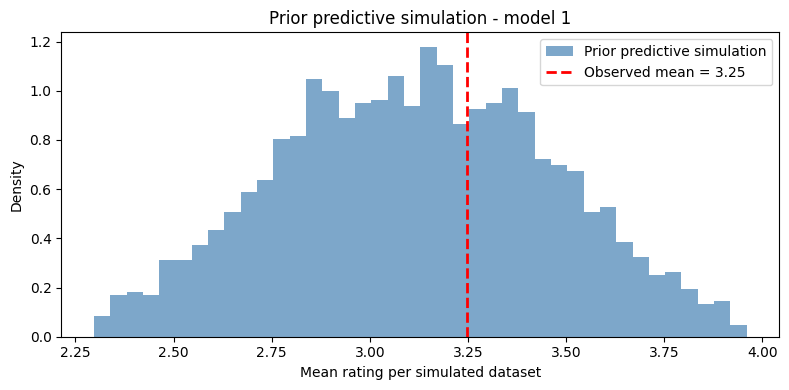

In [10]:
id_to_rating = np.vectorize(inv_rating_map.get)
rating_pred_values = id_to_rating(rating_pred_prior1)

prior_draw_means1 = rating_pred_values.mean(axis=1)
observed_mean = df["Rating"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_draw_means1, bins=40, density=True, alpha=0.7,
        color="steelblue", label="Prior predictive simulation")
ax.axvline(observed_mean, color="red", lw=2, ls="--",
           label=f"Observed mean = {observed_mean:.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Prior predictive simulation - model 1")
ax.legend()
plt.tight_layout()
plt.show()

## posterior model 1

10:02:15 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

10:03:24 - cmdstanpy - INFO - CmdStan done processing.
10:03:24 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -504.891, but should be greater than the previous element, -504.891 (in 'model_1.stan', line 64, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -505.672, but should be greater than the previous element, -505.672 (in 'model_1.stan', line 64, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -125.61, but should be greater than the previous element, -125.61 (in 'model_1.stan', line 64, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -29.9186, but should be greater than the previous element, -29.9186 (in 'model_1.stan', line 64, column 2 to column 36)
	Exception: ordered_logistic: Loca


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


Parameters with R-hat > 1.01: 0

Parameters with ESS < 400: 0


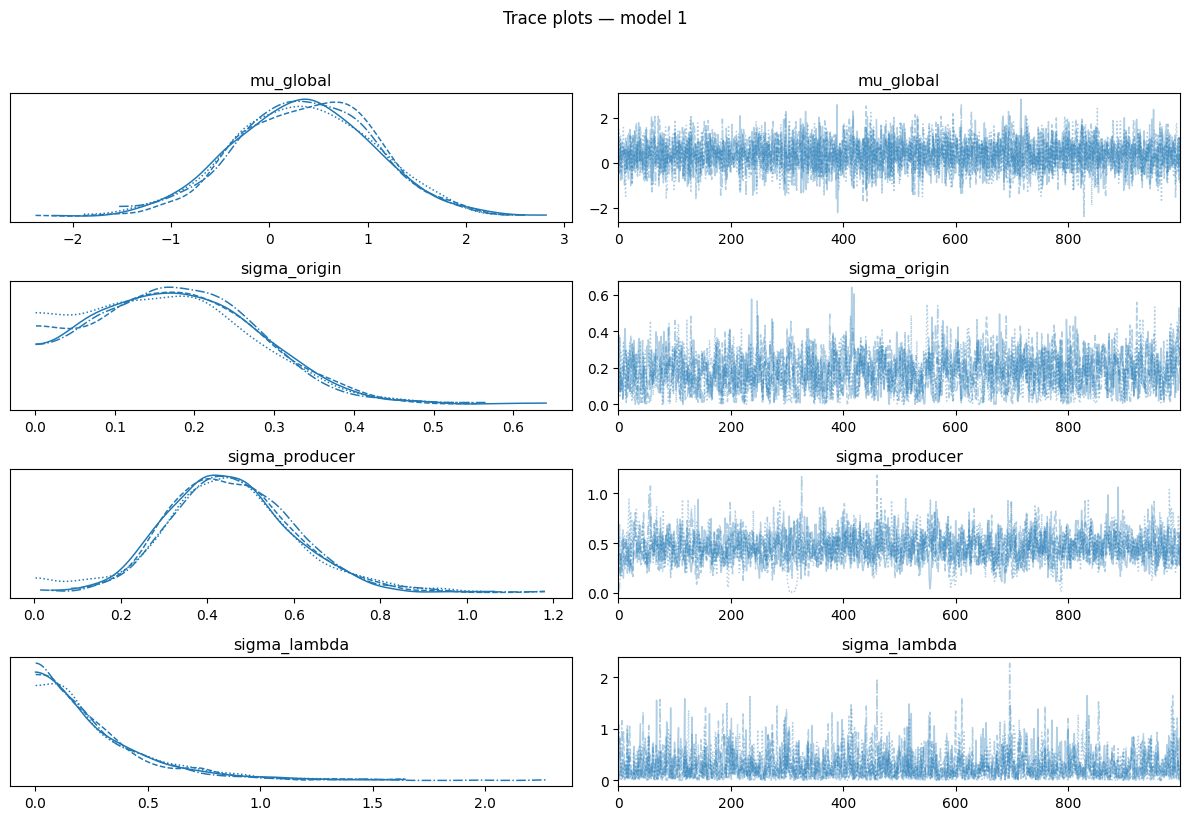

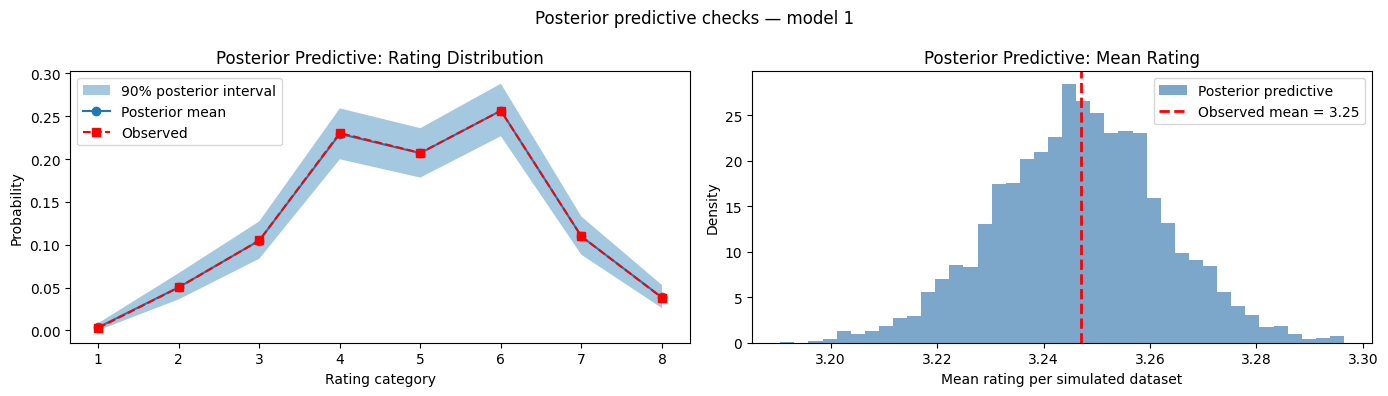

In [25]:
# ── Fit ───────────────────────────────────────────────────────────────────────
model_1_fit = CmdStanModel(stan_file="model_1.stan")

data_sim1 = {
    "N": len(df),
    "J": J,
    "K": K,
    "C": C,
    "origin":          df['Bean Origin ID'].tolist(),
    "producer":        df['Company Location ID'].tolist(),
    "rating":          df['rating_id'].tolist(),
    "origin_location": origin_location,
}

fit1 = model_1_fit.sample(
    data=data_sim1,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True,   # keep on so you can see if chains get stuck
)

# ── Pull posterior samples ─────────────────────────────────────────────────────
# pull posterior samples
# pull posterior samples
rating_pred_post1  = fit1.stan_variable("rating_pred")
alpha_samples1     = fit1.stan_variable("alpha")
gamma_samples1     = fit1.stan_variable("gamma")
lambda_samples1    = fit1.stan_variable("lambda")
sigma_origin1      = fit1.stan_variable("sigma_origin")
sigma_producer1    = fit1.stan_variable("sigma_producer")
sigma_lambda1      = fit1.stan_variable("sigma_lambda")
mu_global_samples1 = fit1.stan_variable("mu_global")
c_samples1         = fit1.stan_variable("c")

# ← this line was missing — map category ids (1–8) back to real rating values
id_to_rating     = np.vectorize(inv_rating_map.get)
rating_pred_vals = id_to_rating(rating_pred_post1)   # (draws, N), values like 2.75, 3.0 etc.

# ← this line was missing — map category ids (1–8) back to real rating values
id_to_rating     = np.vectorize(inv_rating_map.get)
rating_pred_vals = id_to_rating(rating_pred_post1)   # (draws, N), values like 2.75, 3.0 etc.

# ── Convergence diagnostics ───────────────────────────────────────────────────
print(fit1.diagnose())   # divergences, treedepth, E-BFMI — read this carefully

idata1 = az.from_cmdstanpy(fit1)   # convert once, reuse below

summary1 = az.summary(idata1)
bad_rhat = summary1[summary1['r_hat'] > 1.01]
bad_ess  = summary1[summary1['ess_bulk'] < 400]

print(f"\nParameters with R-hat > 1.01: {len(bad_rhat)}")
if len(bad_rhat) > 0:
    print(bad_rhat[['mean','sd','r_hat','ess_bulk']].head(20))

print(f"\nParameters with ESS < 400: {len(bad_ess)}")
if len(bad_ess) > 0:
    print(bad_ess[['mean','sd','r_hat','ess_bulk']].head(20))

# ── Trace plots for global params (visual convergence check) ──────────────────
az.plot_trace(idata1, var_names=["mu_global", "sigma_origin",
                                  "sigma_producer", "sigma_lambda"])
plt.suptitle("Trace plots — model 1", y=1.02)
plt.tight_layout()
plt.show()

# ── Posterior predictive check ────────────────────────────────────────────────
# map predicted category ids back to real rating values
id_to_rating    = np.vectorize(inv_rating_map.get)
pred_values     = id_to_rating(rating_pred_post1)          # (draws, N)

pred_counts = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C),
    1, rating_pred_post1
)
pred_probs = pred_counts / pred_counts.sum(axis=1, keepdims=True)

# observed distribution
obs_counts = np.bincount(df['rating_id'].values.astype(int) - 1, minlength=C)
obs_probs  = obs_counts / obs_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: category-level posterior predictive vs observed
ax = axes[0]
ax.fill_between(
    range(1, C + 1),
    np.percentile(pred_probs, 5,  axis=0),
    np.percentile(pred_probs, 95, axis=0),
    alpha=0.4, label="90% posterior interval"
)
ax.plot(range(1, C + 1), pred_probs.mean(axis=0),
        marker='o', label="Posterior mean")
ax.plot(range(1, C + 1), obs_probs,
        marker='s', color='red', ls='--', label="Observed")
ax.set_xlabel("Rating category")
ax.set_ylabel("Probability")
ax.set_title("Posterior Predictive: Rating Distribution")
ax.legend()

# right: simulated vs observed mean rating
ax = axes[1]
post_means   = pred_values.mean(axis=1)
observed_mean = df["Rating"].mean()
ax.hist(post_means, bins=40, density=True, alpha=0.7,
        color="steelblue", label="Posterior predictive")
ax.axvline(observed_mean, color="red", lw=2, ls="--",
           label=f"Observed mean = {observed_mean:.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Posterior Predictive: Mean Rating")
ax.legend()

plt.suptitle("Posterior predictive checks — model 1")
plt.tight_layout()
plt.show()

Non-fatal warnings occured at the start of the warmup phase but they did not affect the validity of the final posterior draws. The MCMC sampling process was completed successfully with no problems detected. The R_hat values for all parameters are smaller than 1.01 indicating optimal chain convergence. 

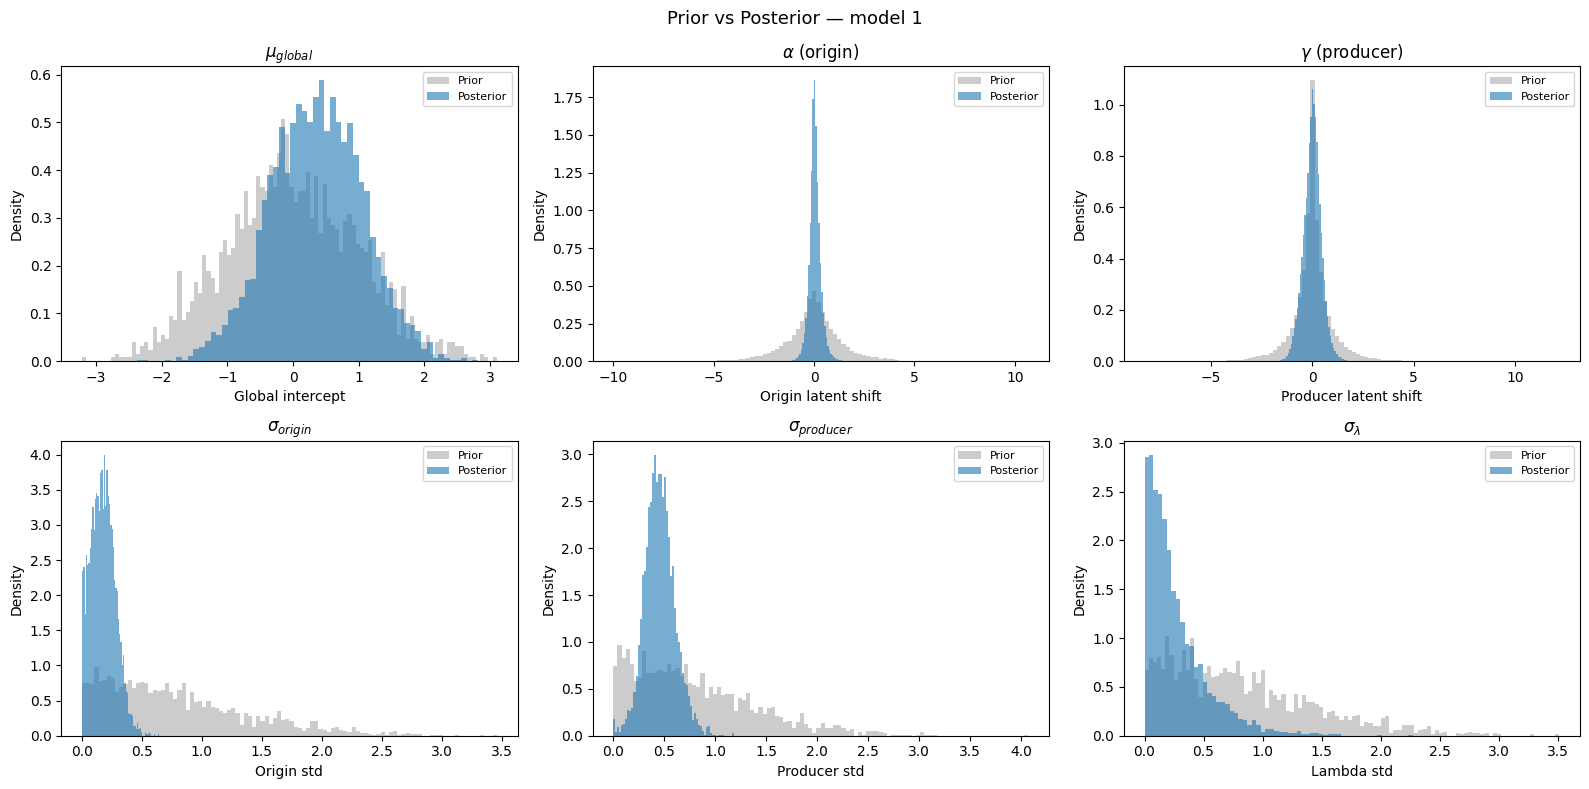

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

panels = [
    (mu_global_samples1,       mu_global_prior1,        r"$\mu_{global}$",        "Global intercept"),
    (alpha_samples1.flatten(), alpha_prior1.flatten(),   r"$\alpha$ (origin)",     "Origin latent shift"),
    (gamma_samples1.flatten(), gamma_prior1.flatten(),   r"$\gamma$ (producer)",   "Producer latent shift"),
    (sigma_origin1,            sigma_origin_prior1,      r"$\sigma_{origin}$",     "Origin std"),
    (sigma_producer1,          sigma_prod_prior1,        r"$\sigma_{producer}$",   "Producer std"),
    (sigma_lambda1,            sigma_lam_prior1,         r"$\sigma_{\lambda}$",    "Lambda std"),
]

for ax, (post, prior, title, xlabel) in zip(axes, panels):
    ax.hist(prior, bins=100, density=True, alpha=0.4, color="gray", label="Prior")
    ax.hist(post,  bins=60,  density=True, alpha=0.6, label="Posterior")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Prior vs Posterior — model 1", fontsize=13)
plt.tight_layout()
plt.show()

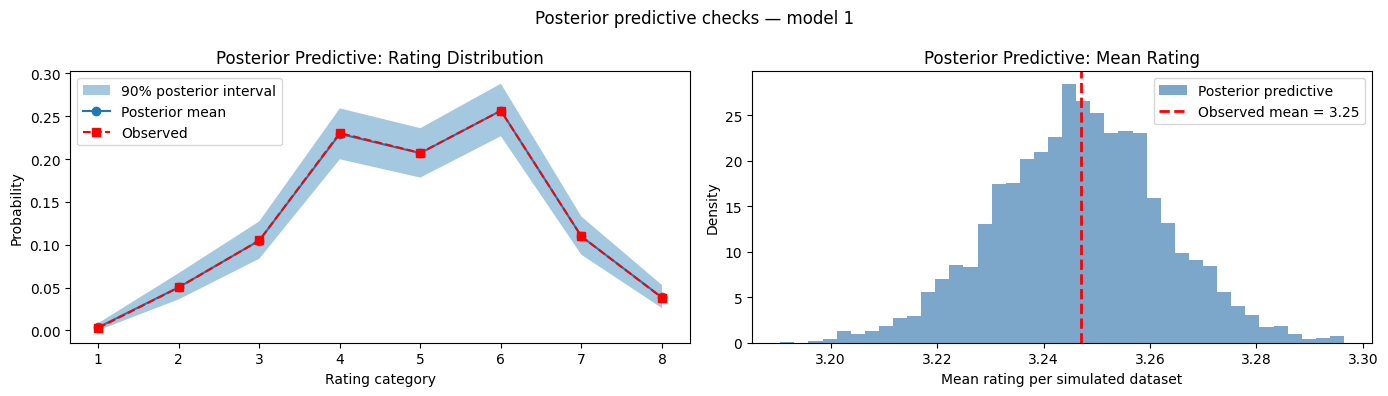

In [30]:
pred_counts = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_post1
)
pred_probs = pred_counts / pred_counts.sum(axis=1, keepdims=True)
obs_counts = np.bincount(df['rating_id'].values.astype(int) - 1, minlength=C)
obs_probs  = obs_counts / obs_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.fill_between(
    range(1, C + 1),
    np.percentile(pred_probs, 5,  axis=0),
    np.percentile(pred_probs, 95, axis=0),
    alpha=0.4, label="90% posterior interval"
)
ax.plot(range(1, C + 1), pred_probs.mean(axis=0), marker='o', label="Posterior mean")
ax.plot(range(1, C + 1), obs_probs, marker='s',
        color='red', ls='--', label="Observed")
ax.set_xlabel("Rating category")
ax.set_ylabel("Probability")
ax.set_title("Posterior Predictive: Rating Distribution")
ax.legend()

ax = axes[1]
ax.hist(rating_pred_vals.mean(axis=1), bins=40, density=True, alpha=0.7,
        color="steelblue", label="Posterior predictive")
ax.axvline(df["Rating"].mean(), color="red", lw=2, ls="--",
           label=f"Observed mean = {df['Rating'].mean():.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Posterior Predictive: Mean Rating")
ax.legend()

plt.suptitle("Posterior predictive checks — model 1")
plt.tight_layout()
plt.show()

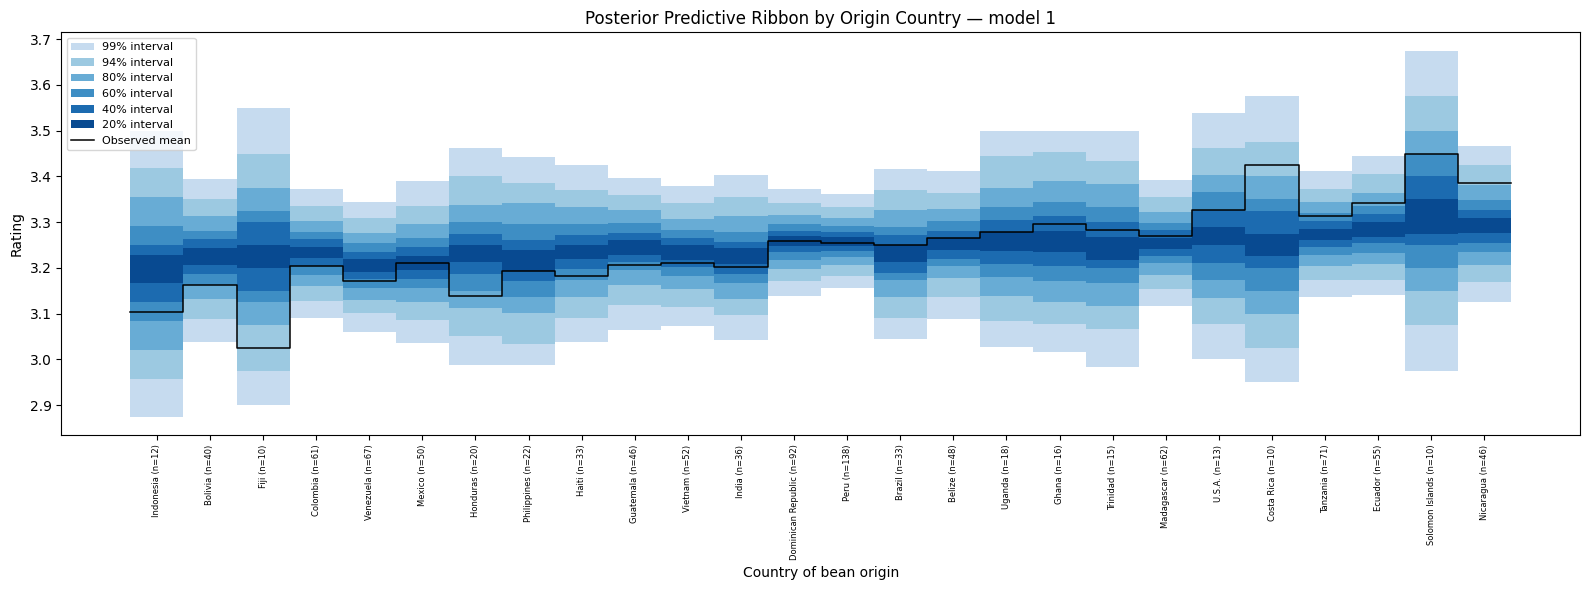

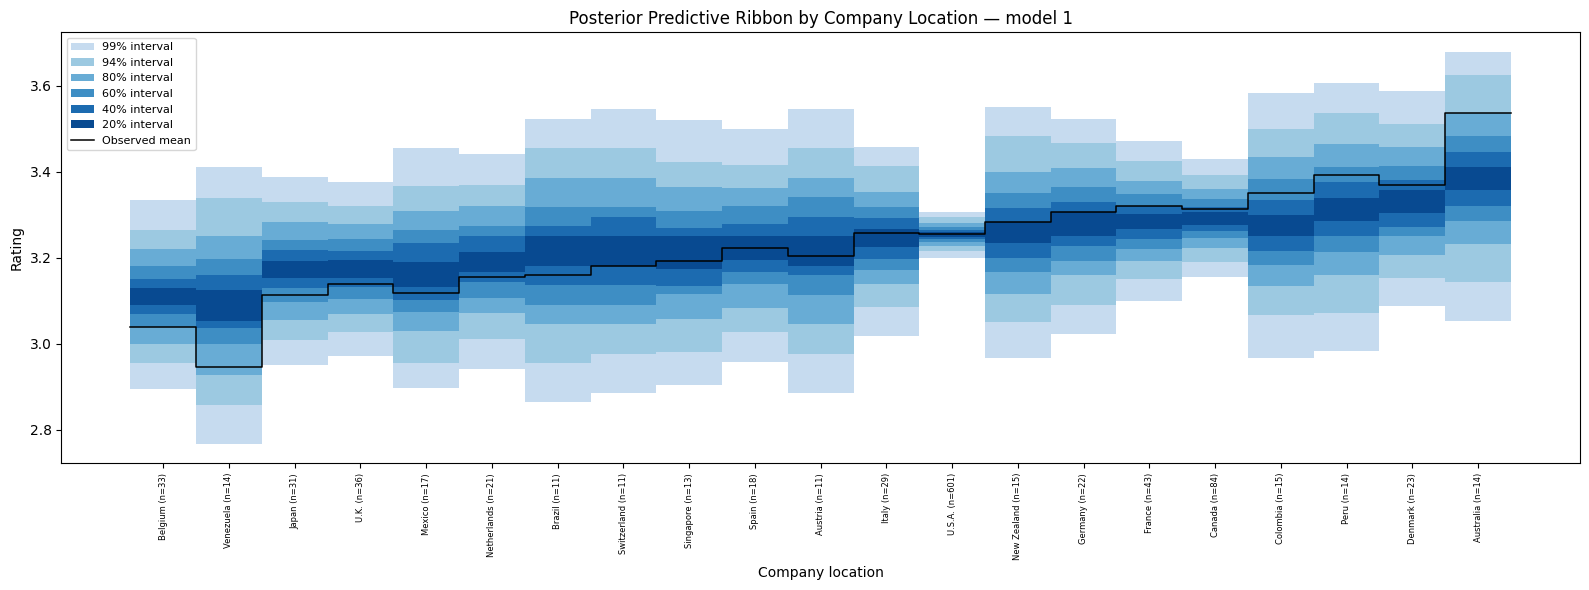

In [ ]:
# ── 3. Ribbon plot by bean origin country ─────────────────────────────────────
# latent score for each origin = global mean + origin effect
mu_origin_total1 = mu_global_samples1[:, None] + alpha_samples1  # (draws, J)

current_df = df.copy().reset_index(drop=True)
countries   = sorted(current_df["Country of Bean Origin"].unique())
country_idx = {c: i + 1 for i, c in enumerate(countries)}
current_df["country_id"] = current_df["Country of Bean Origin"].map(country_idx)
counts_origin = current_df["Country of Bean Origin"].value_counts().to_dict()

results11 = pd.DataFrame({
    "country":     countries,
    "mu_mean":     mu_origin_total1.mean(axis=0),
    "mu_lower_94": np.percentile(mu_origin_total1, 3,  axis=0),
    "mu_upper_94": np.percentile(mu_origin_total1, 97, axis=0),
    "n_bars":      [counts_origin.get(c, 0) for c in countries],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

observed_per_country1 = current_df.groupby("country_id")["Rating"].mean()
obs_sorted_origin = results11["country"].map(
    lambda c: observed_per_country1[country_idx[c]]
).values

J_sorted1 = len(results11)
x2        = np.arange(1, J_sorted1 + 1)
num_draws = rating_pred_vals.shape[0]

post_pred_means_origin = np.zeros((num_draws, J_sorted1))
for i, country_name in enumerate(results11["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == country_name].index.values
    post_pred_means_origin[:, i] = rating_pred_vals[:, idx].mean(axis=1)

def step_edges(values, x):
    edges   = np.concatenate([x - 0.5, x[-1:] + 0.5])
    stepped = np.concatenate([[values[0]], values])
    return edges, stepped

levels = [99, 94, 80, 60, 40, 20]
cmap   = matplotlib.colormaps["Blues"]
colors = [mcolors.to_hex(cmap(f)) for f in np.linspace(0.25, 0.9, len(levels))]

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_means_origin, (100 - lev) / 2,       axis=0)
    hi = np.percentile(post_pred_means_origin, 100 - (100 - lev) / 2, axis=0)
    e, ls = step_edges(lo, x2); _, hs = step_edges(hi, x2)
    ax.fill_between(e, ls, hs, step="pre", color=color,
                    linewidth=0, label=f"{lev}% interval")

e, os = step_edges(obs_sorted_origin, x2)
ax.step(e, os, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x2)
ax.set_xticklabels(
    [f"{r['country']} (n={r['n_bars']})" for _, r in results11.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Country of bean origin"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Origin Country — model 1")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# ── 4. Ribbon plot by company (producer) location ─────────────────────────────
mu_company_total1 = mu_global_samples1[:, None] + gamma_samples1   # (draws, K)

company_locations = sorted(current_df["Company Location"].unique())
company_idx       = {c: i + 1 for i, c in enumerate(company_locations)}
current_df["company_id"] = current_df["Company Location"].map(company_idx)
counts_company = current_df["Company Location"].value_counts().to_dict()

results12 = pd.DataFrame({
    "company":     company_locations,
    "mu_mean":     mu_company_total1.mean(axis=0),
    "mu_lower_94": np.percentile(mu_company_total1, 3,  axis=0),
    "mu_upper_94": np.percentile(mu_company_total1, 97, axis=0),
    "n_bars":      [counts_company.get(c, 0) for c in company_locations],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

observed_per_company1 = current_df.groupby("company_id")["Rating"].mean()
obs_sorted_company = results12["company"].map(
    lambda c: observed_per_company1[company_idx[c]]
).values

K_sorted = len(results12)
x3       = np.arange(1, K_sorted + 1)

post_pred_means_company = np.zeros((num_draws, K_sorted))
for i, comp_name in enumerate(results12["company"]):
    idx = current_df[current_df["Company Location"] == comp_name].index.values
    post_pred_means_company[:, i] = rating_pred_vals[:, idx].mean(axis=1)

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_means_company, (100 - lev) / 2,       axis=0)
    hi = np.percentile(post_pred_means_company, 100 - (100 - lev) / 2, axis=0)
    e, ls = step_edges(lo, x3); _, hs = step_edges(hi, x3)
    ax.fill_between(e, ls, hs, step="pre", color=color,
                    linewidth=0, label=f"{lev}% interval")

e, cs = step_edges(obs_sorted_company, x3)
ax.step(e, cs, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x3)
ax.set_xticklabels(
    [f"{r['company']} (n={r['n_bars']})" for _, r in results12.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Company location"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Company Location — model 1")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

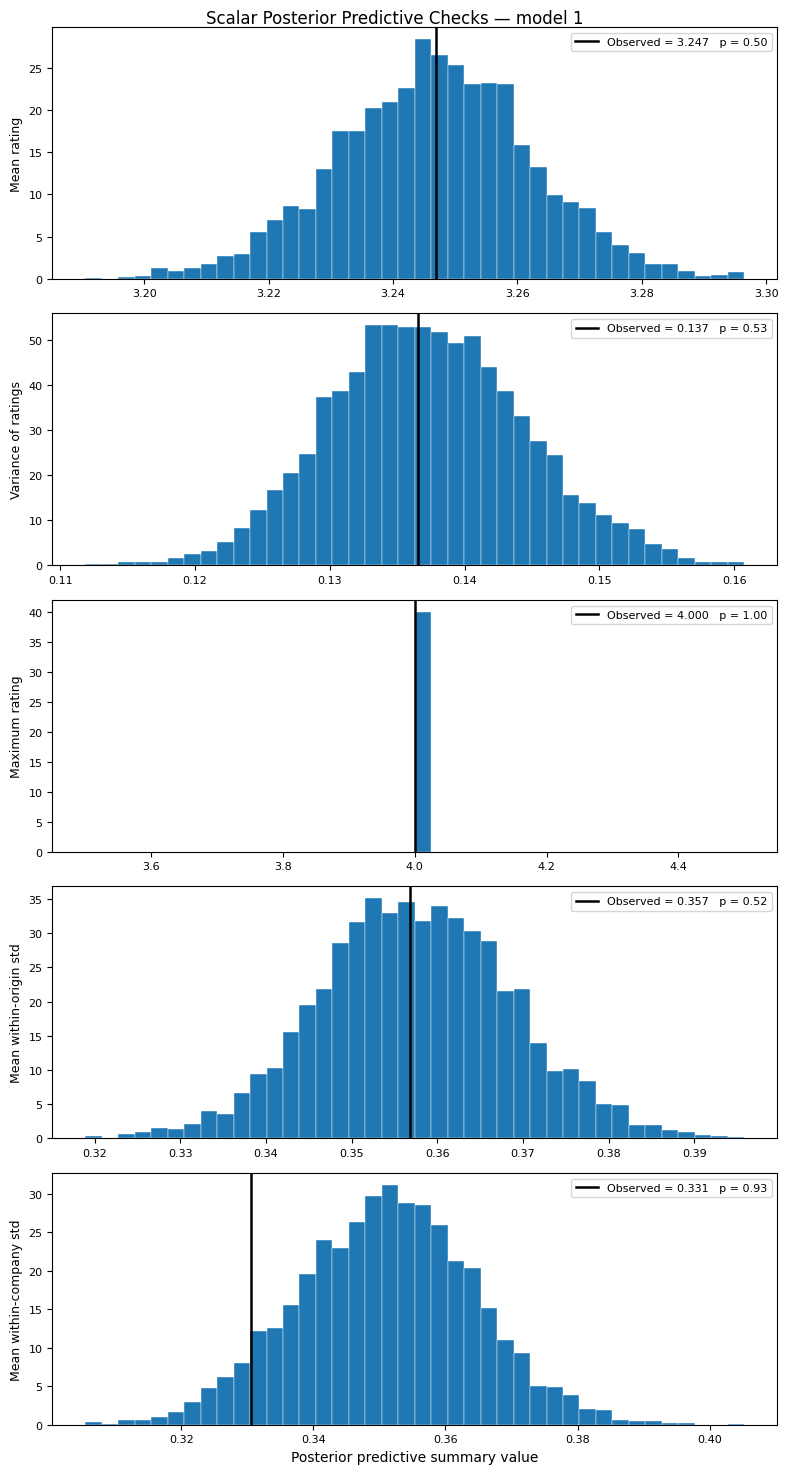

In [ ]:
obs     = df["Rating"].values
y_rep   = rating_pred_vals          # already on real scale

rep_mean = y_rep.mean(axis=1)
rep_var  = y_rep.var(axis=1)
rep_max  = y_rep.max(axis=1)

# within-country std
country_sds_rep = np.zeros((num_draws, J_sorted1))
country_sds_obs = np.zeros(J_sorted1)
for i, country_name in enumerate(results11["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == country_name].index.values
    if len(idx) > 1:
        country_sds_rep[:, i] = y_rep[:, idx].std(axis=1)
        country_sds_obs[i]    = obs[idx].std()
mean_country_sd_rep = country_sds_rep.mean(axis=1)
mean_country_sd_obs = country_sds_obs.mean()

# within-company std
company_sds_rep = np.zeros((num_draws, K_sorted))
company_sds_obs = np.zeros(K_sorted)
for i, comp_name in enumerate(results12["company"]):
    idx = current_df[current_df["Company Location"] == comp_name].index.values
    if len(idx) > 1:
        company_sds_rep[:, i] = y_rep[:, idx].std(axis=1)
        company_sds_obs[i]    = obs[idx].std()
mean_company_sd_rep = company_sds_rep.mean(axis=1)
mean_company_sd_obs = company_sds_obs.mean()

checks = [
    (rep_mean,           obs.mean(),          "Mean rating"),
    (rep_var,            obs.var(),           "Variance of ratings"),
    (rep_max,            obs.max(),           "Maximum rating"),
    (mean_country_sd_rep, mean_country_sd_obs, "Mean within-origin std"),
    (mean_company_sd_rep, mean_company_sd_obs, "Mean within-company std"),
]

fig, axes = plt.subplots(5, 1, figsize=(8, 15))
for ax, (rep_stat, obs_stat, ylabel) in zip(axes, checks):
    ax.hist(rep_stat, bins=40, density=True, edgecolor="white", linewidth=0.3)
    p_val = np.mean(rep_stat >= obs_stat)
    ax.axvline(obs_stat, color="k", linewidth=1.8,
               label=f"Observed = {obs_stat:.3f}   p = {p_val:.2f}")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel("Posterior predictive summary value", fontsize=10)
plt.suptitle("Scalar Posterior Predictive Checks — model 1", fontsize=12)
plt.tight_layout()
plt.show()

## Model 2


In [ ]:
J = max(df["Bean Origin ID"])
K = max(df["Company Location ID"])

prior_model3 = CmdStanModel(stan_file="prior_model3.stan")

prior_data3 = {
    "N": len(df),
    "J": J,
    "K": K,
    "country":         df["Bean Origin ID"].tolist(),
    "location":        df["Company Location ID"].tolist(),
    "cocoa_pct_std":   df["Cocoa Percent norm"].tolist(),
    "n_ingredients":   df["Number of ingredients"].tolist(),
    "has_vanilla":     df["Has vanilla"].tolist(),
    "year_std":        df["Year Norm"].tolist(),
}

prior_fit3 = prior_model3.sample(
    data=prior_data3,
    fixed_param=True,
    iter_sampling=2000,
    chains=1,
    seed=42,
    show_progress=False,
)

rating_pred_prior3 = prior_fit3.stan_variable("rating_pred")
a_prior_draws3      = prior_fit3.stan_variable("a")
b_prior_draws3       = prior_fit3.stan_variable("b")
mu_global_prior3     = prior_fit3.stan_variable("mu_global")
sigma_prior_draws3   = prior_fit3.stan_variable("sigma")
beta_cocoa1_prior3   = prior_fit3.stan_variable("beta_cocoa1")
beta_cocoa2_prior3   = prior_fit3.stan_variable("beta_cocoa2")
beta_ingredients_prior3 = prior_fit3.stan_variable("beta_ingredients")
beta_vanilla_prior3 = prior_fit3.stan_variable("beta_vanilla")
beta_year_prior3    = prior_fit3.stan_variable("beta_year")

19:26:51 - cmdstanpy - INFO - CmdStan start processing
19:26:51 - cmdstanpy - INFO - Chain [1] start processing
19:26:51 - cmdstanpy - INFO - Chain [1] done processing


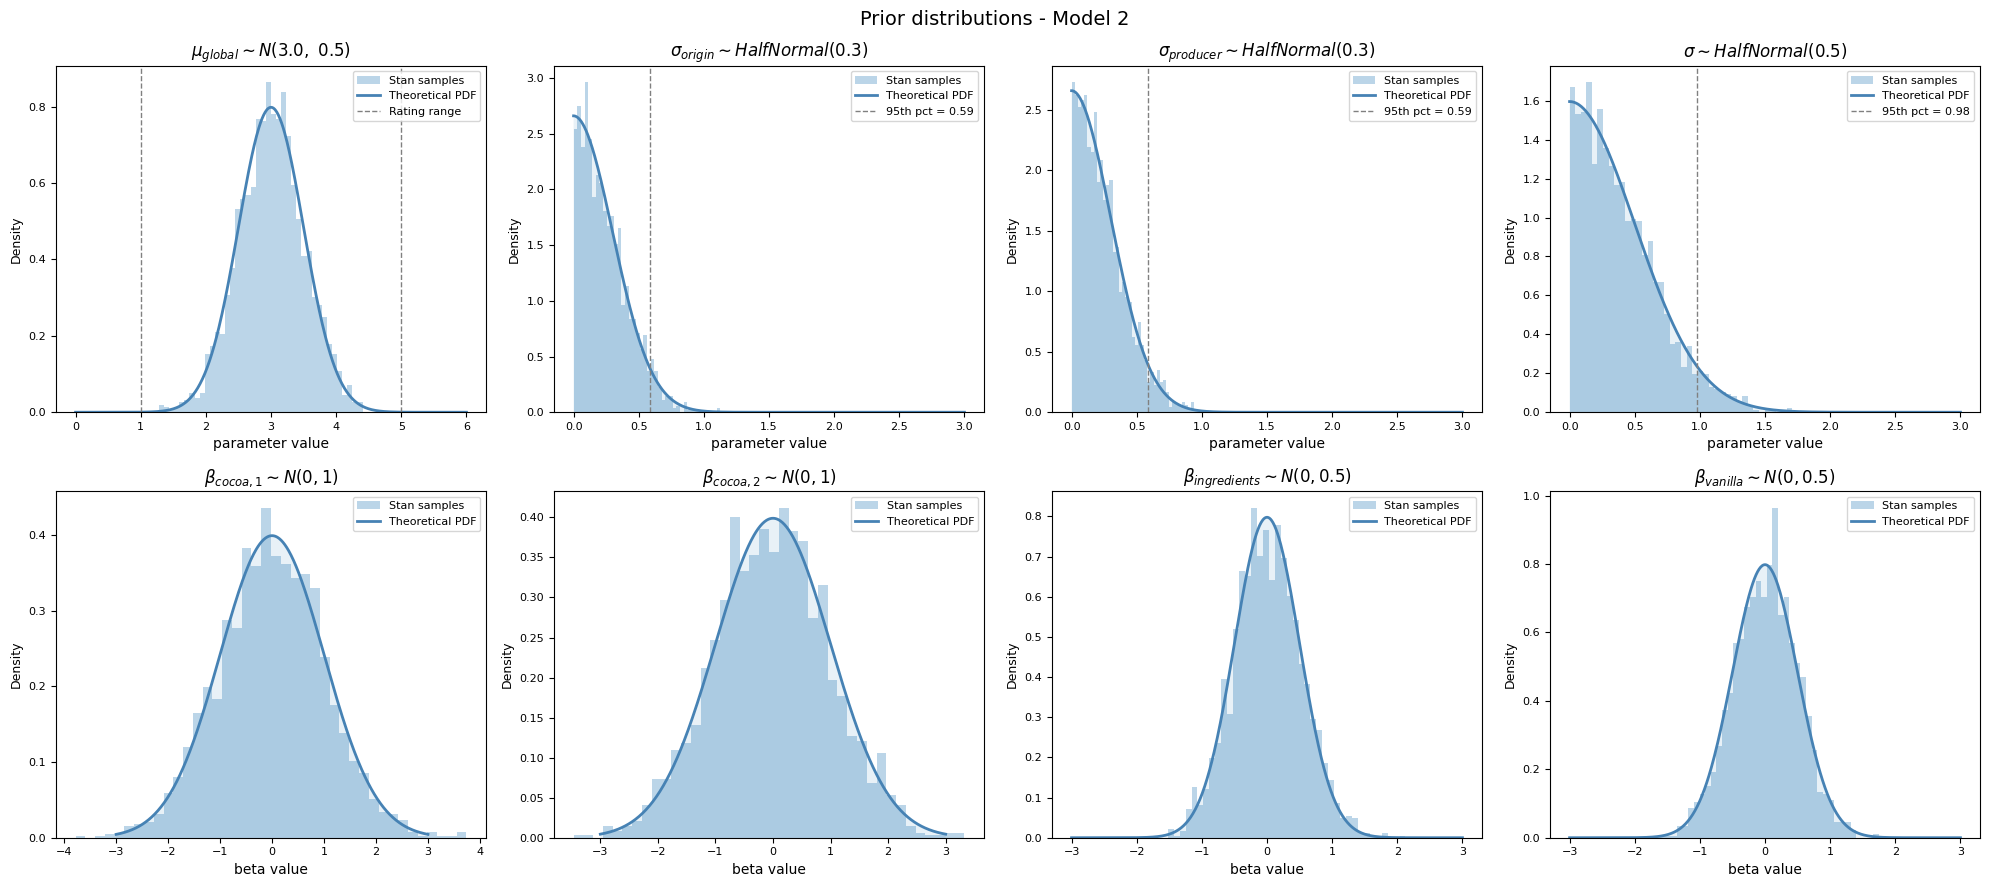

In [ ]:
x_mu = np.linspace(0, 6, 500)
x_sigma = np.linspace(0, 3, 500)
x_beta = np.linspace(-3, 3, 500)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

axes[0, 0].hist(mu_global_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
axes[0, 0].plot(x_mu, stats.norm.pdf(x_mu, loc=3.0, scale=0.5), lw=2, color='steelblue', label="Theoretical PDF")
axes[0, 0].axvline(1, color="gray", ls="--", lw=1)
axes[0, 0].axvline(5, color="gray", ls="--", lw=1, label="Rating range")
axes[0, 0].set_title(r"$\mu_{global} \sim N(3.0,\ 0.5)$")
axes[0, 0].set_xlabel("rating")
axes[0, 0].legend(fontsize=8)

try:
    sigma_origin_prior3 = prior_fit3.stan_variable("sigma_origin")
    axes[0, 1].hist(sigma_origin_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
except:
    pass
axes[0, 1].plot(x_sigma, stats.halfnorm.pdf(x_sigma, scale=0.3), lw=2, color='steelblue', label="Theoretical PDF")
axes[0, 1].fill_between(x_sigma, stats.halfnorm.pdf(x_sigma, scale=0.3), alpha=0.1)
axes[0, 1].axvline(stats.halfnorm.ppf(0.95, scale=0.3), color="gray", ls="--", lw=1,
                   label=f"95th pct = {stats.halfnorm.ppf(0.95, scale=0.3):.2f}")
axes[0, 1].set_title(r"$\sigma_{origin} \sim HalfNormal(0.3)$")
axes[0, 1].set_xlabel("between-origin std")
axes[0, 1].legend(fontsize=8)


try:
    sigma_producer_prior3 = prior_fit3.stan_variable("sigma_producer")
    axes[0, 2].hist(sigma_producer_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
except:
    pass
axes[0, 2].plot(x_sigma, stats.halfnorm.pdf(x_sigma, scale=0.3), lw=2, color='steelblue', label="Theoretical PDF")
axes[0, 2].fill_between(x_sigma, stats.halfnorm.pdf(x_sigma, scale=0.3), alpha=0.1)
axes[0, 2].axvline(stats.halfnorm.ppf(0.95, scale=0.3), color="gray", ls="--", lw=1,
                   label=f"95th pct = {stats.halfnorm.ppf(0.95, scale=0.3):.2f}")
axes[0, 2].set_title(r"$\sigma_{producer} \sim HalfNormal(0.3)$")
axes[0, 2].set_xlabel("between-producer std")
axes[0, 2].legend(fontsize=8)


axes[0, 3].hist(sigma_prior_draws3, bins=40, density=True, alpha=0.3, label="Stan samples")
axes[0, 3].plot(x_sigma, stats.halfnorm.pdf(x_sigma, scale=0.5), lw=2, color='steelblue', label="Theoretical PDF")
axes[0, 3].fill_between(x_sigma, stats.halfnorm.pdf(x_sigma, scale=0.5), alpha=0.1)
axes[0, 3].axvline(stats.halfnorm.ppf(0.95, scale=0.5), color="gray", ls="--", lw=1,
                   label=f"95th pct = {stats.halfnorm.ppf(0.95, scale=0.5):.2f}")
axes[0, 3].set_title(r"$\sigma \sim HalfNormal(0.5)$")
axes[0, 3].set_xlabel("within-group std")
axes[0, 3].legend(fontsize=8)


axes[1, 0].hist(beta_cocoa1_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
axes[1, 0].plot(x_beta, stats.norm.pdf(x_beta, 0, 1), lw=2, color='steelblue', label="Theoretical PDF")
axes[1, 0].fill_between(x_beta, stats.norm.pdf(x_beta, 0, 1), alpha=0.1)
axes[1, 0].set_title(r"$\beta_{cocoa,1} \sim N(0, 1)$")
axes[1, 0].legend(fontsize=8)

axes[1, 1].hist(beta_cocoa2_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
axes[1, 1].plot(x_beta, stats.norm.pdf(x_beta, 0, 1), lw=2, color='steelblue', label="Theoretical PDF")
axes[1, 1].fill_between(x_beta, stats.norm.pdf(x_beta, 0, 1), alpha=0.1)
axes[1, 1].set_title(r"$\beta_{cocoa,2} \sim N(0, 1)$")
axes[1, 1].legend(fontsize=8)

axes[1, 2].hist(beta_ingredients_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
axes[1, 2].plot(x_beta, stats.norm.pdf(x_beta, 0, 0.5), lw=2, color='steelblue', label="Theoretical PDF")
axes[1, 2].fill_between(x_beta, stats.norm.pdf(x_beta, 0, 0.5), alpha=0.1)
axes[1, 2].set_title(r"$\beta_{ingredients} \sim N(0, 0.5)$")
axes[1, 2].legend(fontsize=8)

axes[1, 3].hist(beta_vanilla_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
axes[1, 3].plot(x_beta, stats.norm.pdf(x_beta, 0, 0.5), lw=2, color='steelblue', label="Theoretical PDF")
axes[1, 3].fill_between(x_beta, stats.norm.pdf(x_beta, 0, 0.5), alpha=0.1)
axes[1, 3].set_title(r"$\beta_{vanilla} \sim N(0, 0.5)$")
axes[1, 3].legend(fontsize=8)

for ax in axes.flat:
    ax.set_ylabel("Density", fontsize=9)
    ax.tick_params(labelsize=8)

for ax in axes[0, :]:
    ax.set_xlabel("parameter value")
for ax in axes[1, :]:
    ax.set_xlabel("beta value")

plt.suptitle("Prior distributions - Model 2", fontsize=14)
plt.tight_layout()
plt.show()

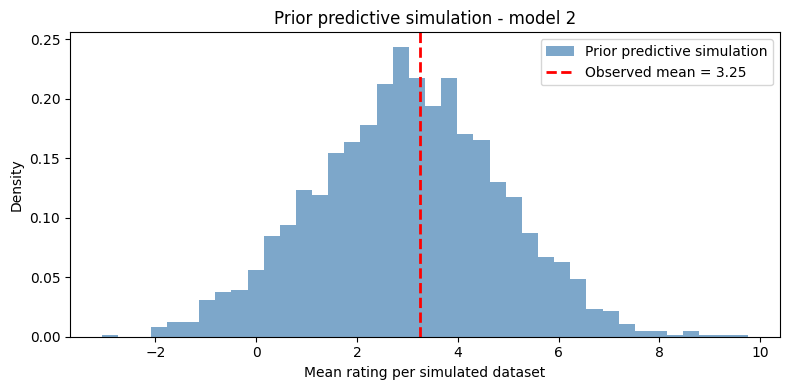

In [ ]:
prior_draw_means3 = rating_pred_prior3.mean(axis=1)
observed_mean = df["Rating"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_draw_means3, bins=40, density=True, alpha=0.7,
        color="steelblue", label="Prior predictive simulation")
ax.axvline(observed_mean, color="red", lw=2, ls="--",
           label=f"Observed mean = {observed_mean:.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Prior predictive simulation - model 2")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
model_3_fit = CmdStanModel(stan_file="model_3.stan")

data_sim3 = {
    "N": len(df),
    "J": J,
    "K": K,
    "country":         df["Bean Origin ID"].tolist(),
    "location":        df["Company Location ID"].tolist(),
    "cocoa_pct_std":   df["Cocoa Percent norm"].tolist(),
    "n_ingredients":   df["Number of ingredients"].tolist(),
    "has_vanilla":     df["Has vanilla"].tolist(),
    "year_std":        df["Year Norm"].tolist(),
    "rating":          df["Rating"].tolist(),
}

fit3 = model_3_fit.sample(
    data=data_sim3,
    seed=42,
    chains=4,
    show_progress=False,
)

print(fit3.summary())
print(fit3.diagnose())

rating_pred_post3 = fit3.stan_variable("rating_pred")
a_samples3         = fit3.stan_variable("a")
b_samples3         = fit3.stan_variable("b")
sigma_samples3      = fit3.stan_variable("sigma")
mu_global_samples3  = fit3.stan_variable("mu_global")
beta_cocoa1_samples3      = fit3.stan_variable("beta_cocoa1")
beta_cocoa2_samples3      = fit3.stan_variable("beta_cocoa2")
beta_ingredients_samples3 = fit3.stan_variable("beta_ingredients")
beta_vanilla_samples3     = fit3.stan_variable("beta_vanilla")
beta_year_samples3        = fit3.stan_variable("beta_year")

19:26:24 - cmdstanpy - INFO - Chain [2] done processing
--- Logging error ---
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/logging/__init__.py", line 1113, in emit
    stream.write(msg + self.terminator)
  File "/usr/local/lib/python3.11/site-packages/ipykernel/iostream.py", line 694, in write
    self._schedule_flush()
  File "/usr/local/lib/python3.11/site-packages/ipykernel/iostream.py", line 590, in _schedule_flush
    self.pub_thread.schedule(_schedule_in_thread)
  File "/usr/local/lib/python3.11/site-packages/ipykernel/iostream.py", line 267, in schedule
    self._event_pipe.send(b"")
  File "/usr/local/lib/python3.11/site-packages/zmq/sugar/socket.py", line 710, in send
    return super().send(data, flags=flags, copy=copy, track=track)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "_zmq.py", line 1092, in zmq.backend.cython._zmq.Socket.send
  File "_zmq.py", line 1134, in zmq.backend.cython._zmq.Socket.send
  File "_zmq.py", li

Similarly to model 1, non-fatal warrnings occured at the warmup phase. The final posterior draws were valid and the MCMC sampling completed without errors.

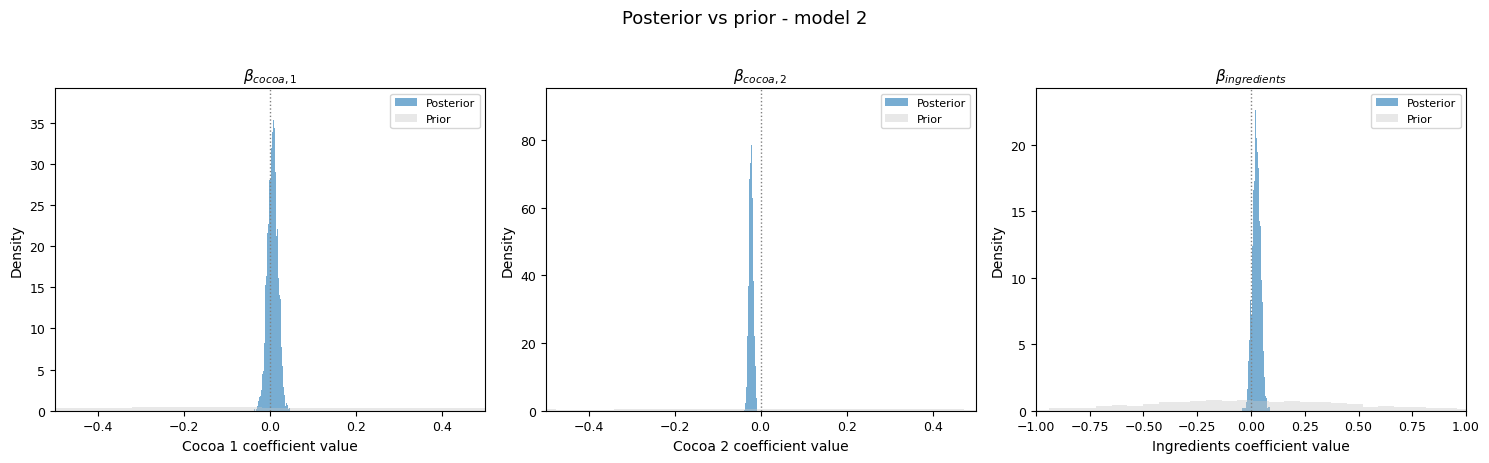

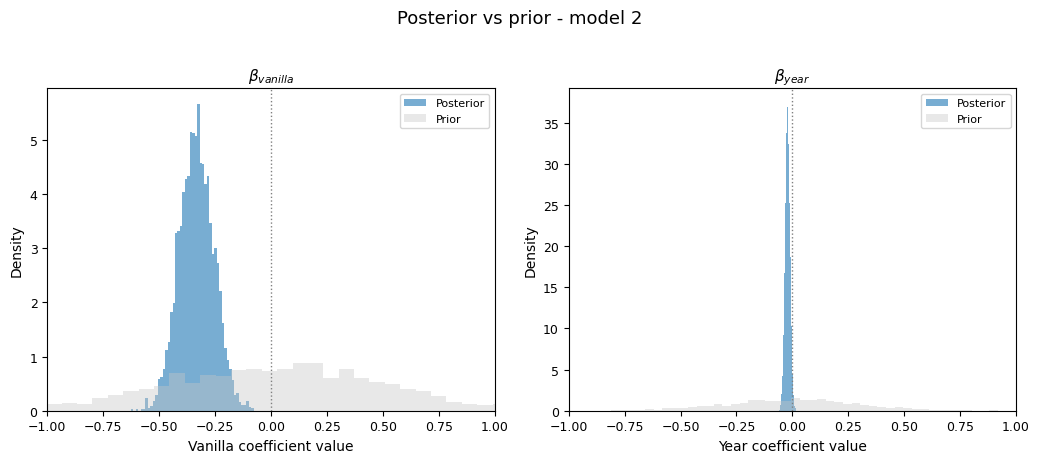

In [ ]:
all_coefs = [
    (beta_cocoa1_samples3, beta_cocoa1_prior3, r"$\beta_{cocoa,1}$", "Cocoa 1 coefficient value", (-0.5, 0.5)),
    (beta_cocoa2_samples3, beta_cocoa2_prior3, r"$\beta_{cocoa,2}$", "Cocoa 2 coefficient value", (-0.5, 0.5)),
    (beta_ingredients_samples3, beta_ingredients_prior3, r"$\beta_{ingredients}$", "Ingredients coefficient value", (-1, 1)),
    (beta_vanilla_samples3, beta_vanilla_prior3, r"$\beta_{vanilla}$", "Vanilla coefficient value", (-1, 1)),
    (beta_year_samples3, beta_year_prior3, r"$\beta_{year}$", "Year coefficient value", (-1, 1)),
]

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (post, prior, label, x_label, limit) in zip(axes1, all_coefs[:3]):
    ax.hist(post, bins=50, density=True, alpha=0.6, color="#1f77b4", label="Posterior")
    ax.hist(prior, bins=50, density=True, alpha=0.4, color="#c7c7c7", label="Prior")
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)
    
    ax.set_title(label, fontsize=11)
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_xlim(limit[0], limit[1]) 
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(labelsize=9)

plt.suptitle("Posterior vs prior - model 2", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(10.5, 4.5))

for ax, (post, prior, label, x_label, limit) in zip(axes2, all_coefs[3:]):
    ax.hist(post, bins=50, density=True, alpha=0.6, color="#1f77b4", label="Posterior")
    ax.hist(prior, bins=50, density=True, alpha=0.4, color="#c7c7c7", label="Prior")
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)
    
    ax.set_title(label, fontsize=11)
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_xlim(limit[0], limit[1]) 
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(labelsize=9)

plt.suptitle("Posterior vs prior - model 2", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

All five coefficient posteriors are significantly narrower than their respective priors, confirming that the likelihood dominates and the data, not the prior specification.
For the cocoa the posterior concentrates tightly around +0.05,  within the prior range but shifted slightly positive. For the quadratic, the posterior is shifted to -0.12. This is the strongest signal in the model, showing that the cocoa percentage has a concave relationship with rating.

For the number of ingredients, the posterior is centered near zero with a very narrow spread, and the credible interval includes zero. There is no credible effect of ingredient count on rating once origin, producer, and other covariates are accounted for.

The posterior for the vanilla presence is approximately -0.31 and the credible interval excludes zero, making this the strongest categorical signal in the model. Bars containing vanilla receive credibly lower ratings on average,  consistent with craft chocolate criticism that vanilla masks bean character. 

For the year of the review, the posterior is centered very close to zero with negligible spread. There is no credible temporal trend in ratings across the 2016–2026 period. 


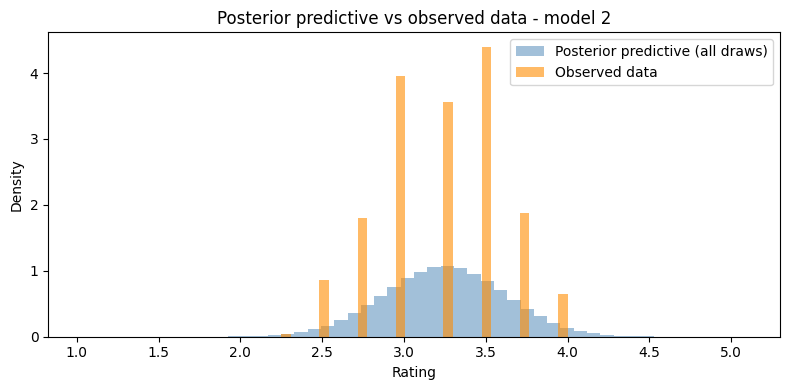

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rating_pred_post3.flatten(), bins=50, density=True, alpha=0.5,
        color="steelblue", label="Posterior predictive (all draws)")
ax.hist(df["Rating"], bins=30, density=True, alpha=0.6,
        color="darkorange", label="Observed data")
ax.set_xlabel("Rating")
ax.set_ylabel("Density")
ax.set_title("Posterior predictive vs observed data - model 2")
ax.legend()
plt.tight_layout()
plt.show()

Posterior predictive distribution succesfully replicates location and spread of the observed data, as in model 1.

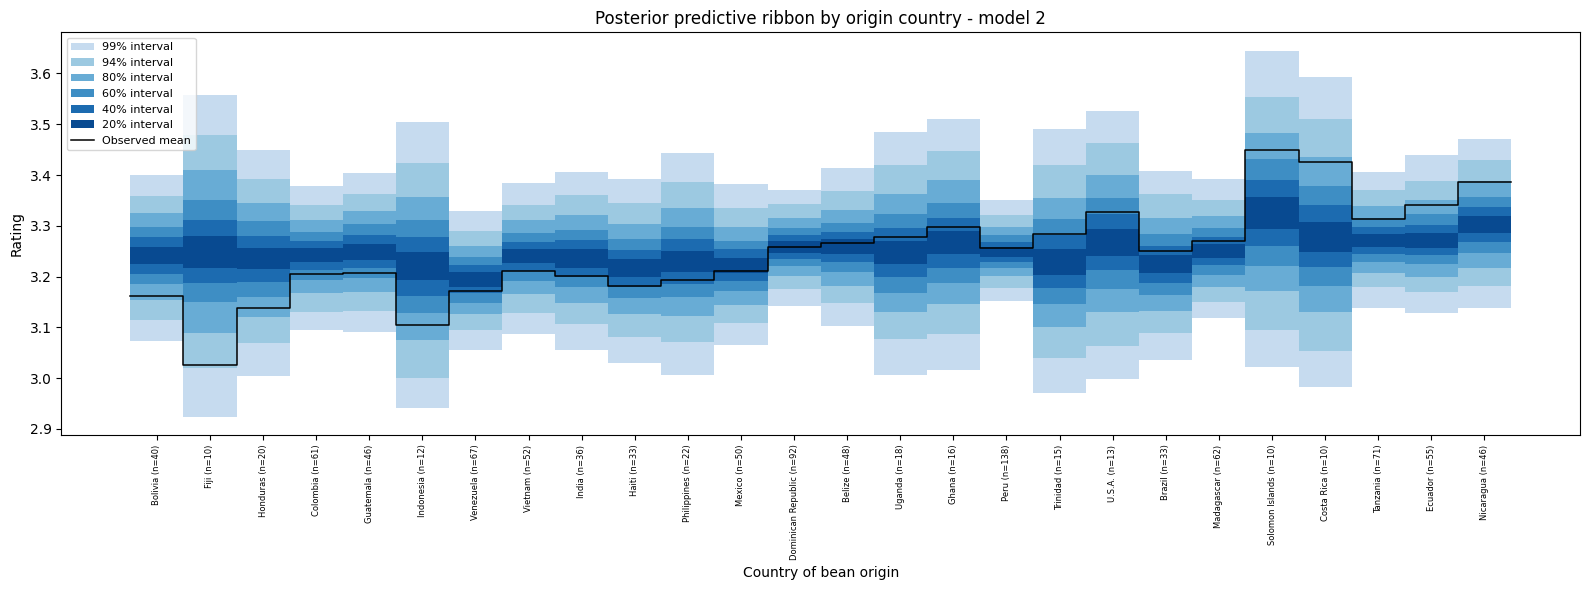

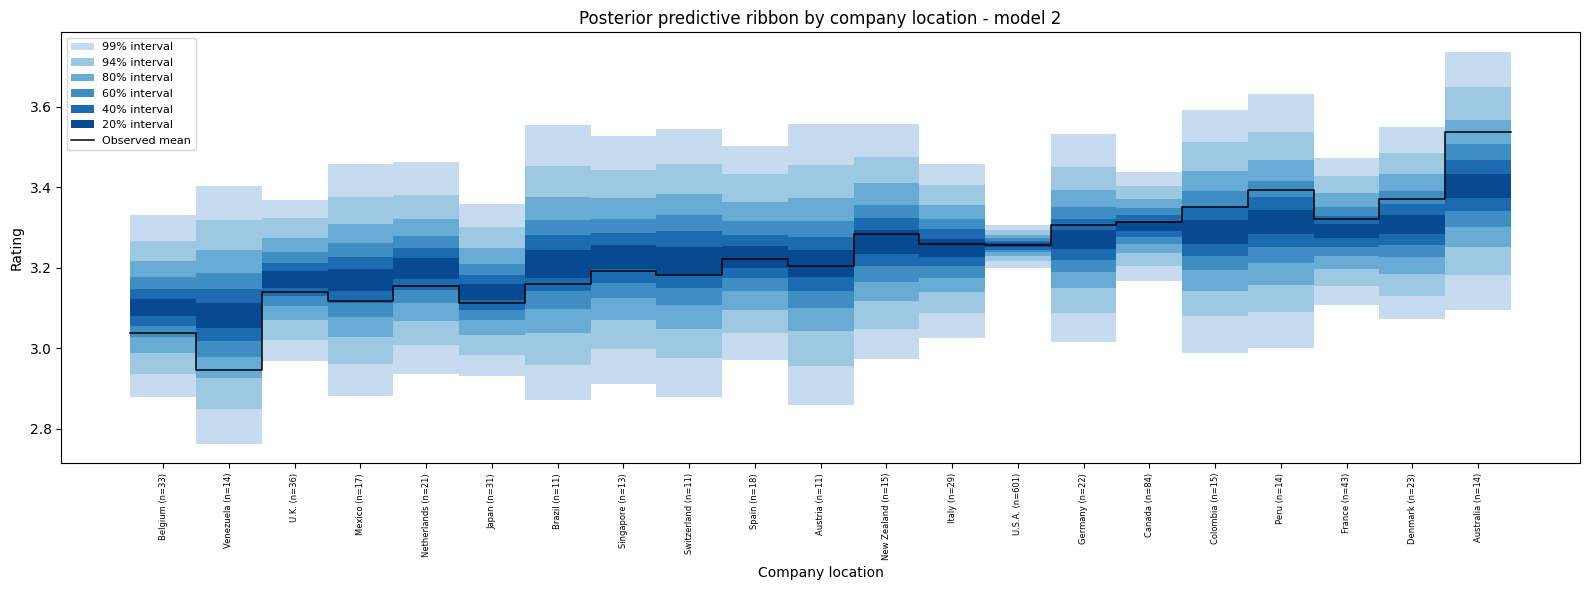

In [ ]:
counts_origin = df["Country of Bean Origin"].value_counts()

mu_country_total3 = mu_global_samples3[:, None] + a_samples3 

results3 = pd.DataFrame({
    "country":     countries,
    "mu_mean":     mu_country_total3.mean(axis=0),
    "mu_lower_94": np.percentile(mu_country_total3, 3, axis=0),
    "mu_upper_94": np.percentile(mu_country_total3, 97, axis=0),
    "n_bars":      [counts_origin.get(c, 0) for c in countries],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)
df_reset3 = df.reset_index(drop=True)

observed_per_country3 = df_reset3.groupby("Bean Origin ID")["Rating"].mean()
obs_sorted3 = results3["country"].map(lambda c: observed_per_country3[country_idx[c]]).values

num_samples3 = rating_pred_post3.shape[0]
J_sorted3 = len(results3)
x3 = np.arange(1, J_sorted3 + 1)

post_pred_means_sorted3 = np.zeros((num_samples3, J_sorted3))
for i, country_name in enumerate(results3["country"]):
    country_id_val = country_idx[country_name]
    obs_indices = df_reset3[df_reset3["Bean Origin ID"] == country_id_val].index.values
    post_pred_means_sorted3[:, i] = rating_pred_post3[:, obs_indices].mean(axis=1)

levels = [99, 94, 80, 60, 40, 20]
bands3 = {}
for lev in levels:
    lo = (100 - lev) / 2
    hi = 100 - lo
    bands3[lev] = (
        np.percentile(post_pred_means_sorted3, lo, axis=0),
        np.percentile(post_pred_means_sorted3, hi, axis=0),
    )

def step_edges(values, x):
    edges = np.concatenate([x - 0.5, x[-1:] + 0.5])
    stepped = np.concatenate([[values[0]], values])
    return edges, stepped

cmap = matplotlib.colormaps["Blues"]
fracs = np.linspace(0.25, 0.9, len(levels))
colors = [mcolors.to_hex(cmap(f)) for f in fracs]

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo, hi = bands3[lev]
    edges_lo, lo_step = step_edges(lo, x3)
    _, hi_step = step_edges(hi, x3)
    ax.fill_between(edges_lo, lo_step, hi_step, step="pre",
                    color=color, linewidth=0, label=f"{lev}% interval")

edges_obs3, obs_step3 = step_edges(obs_sorted3, x3)
ax.step(edges_obs3, obs_step3, where="pre", color="black",
        linewidth=1.1, label="Observed mean")

ax.set_xticks(x3)
ax.set_xticklabels(
    [f"{r['country']} (n={r['n_bars']})" for _, r in results3.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Country of bean origin")
ax.set_ylabel("Rating")
ax.set_title("Posterior predictive ribbon by origin country - model 2")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


# ==-------------------------------------------------------
counts_location = df["Company Location"].value_counts()
locations = sorted(df["Company Location"].unique())
location_idx = {name: i + 1 for i, name in enumerate(locations)}
location_names = [name for name, idx in sorted(location_idx.items(), key=lambda item: item[1])]

mu_location_total3 = mu_global_samples3[:, None] + b_samples3
results_loc3 = pd.DataFrame({
    "location":   location_names,
    "mu_mean":    mu_location_total3.mean(axis=0),
    "n_bars":     [counts_location.get(c, 0) for c in location_names],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

observed_per_loc3 = df_reset3.groupby("Company Location ID")["Rating"].mean()
obs_sorted_loc3 = results_loc3["location"].map(lambda l: observed_per_loc3[location_idx[l]]).values


num_samples3 = rating_pred_post3.shape[0]
K_sorted3 = len(results_loc3)
x_loc3 = np.arange(1, K_sorted3 + 1)

post_pred_means_loc3 = np.zeros((num_samples3, K_sorted3))
for i, loc_name in enumerate(results_loc3["location"]):
    loc_id_val = location_idx[loc_name]
    obs_indices = df_reset3[df_reset3["Company Location ID"] == loc_id_val].index.values
    post_pred_means_loc3[:, i] = rating_pred_post3[:, obs_indices].mean(axis=1)

levels = [99, 94, 80, 60, 40, 20]
bands_loc3 = {}
for lev in levels:
    lo = (100 - lev) / 2
    hi = 100 - lo
    bands_loc3[lev] = (
        np.percentile(post_pred_means_loc3, lo, axis=0),
        np.percentile(post_pred_means_loc3, hi, axis=0),
    )


fig, ax = plt.subplots(figsize=(16, 6))
cmap = matplotlib.colormaps["Blues"]
fracs = np.linspace(0.25, 0.9, len(levels))
colors = [mcolors.to_hex(cmap(f)) for f in fracs]

for lev, color in zip(levels, colors):
    lo, hi = bands_loc3[lev]
    edges_lo, lo_step = step_edges(lo, x_loc3)
    _, hi_step = step_edges(hi, x_loc3)
    ax.fill_between(edges_lo, lo_step, hi_step, step="pre",
                    color=color, linewidth=0, label=f"{lev}% interval")

edges_obs_loc3, obs_step_loc3 = step_edges(obs_sorted_loc3, x_loc3)
ax.step(edges_obs_loc3, obs_step_loc3, where="pre", color="black",
        linewidth=1.1, label="Observed mean")

ax.set_xticks(x_loc3)
ax.set_xticklabels(
    [f"{r['location']} (n={r['n_bars']})" for _, r in results_loc3.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Company location")
ax.set_ylabel("Rating")
ax.set_title("Posterior predictive ribbon by company location - model 2")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


Origin-country ribbon shows slightly narrower intervals compared to Model 1's, particularly for well-sampled countries like Peru and Dominican Republic. This reflects the added covariates explaining the residual varince from model 2 better. The company-location ribbon reveals a clearer ranking pattern than the origin ribbon, with producer countries like Australia, Denmark and France sitting credibly above Belgium and Venezuela, showing that where chocolate is made is more influential source of rating variation than where the beans come from. 

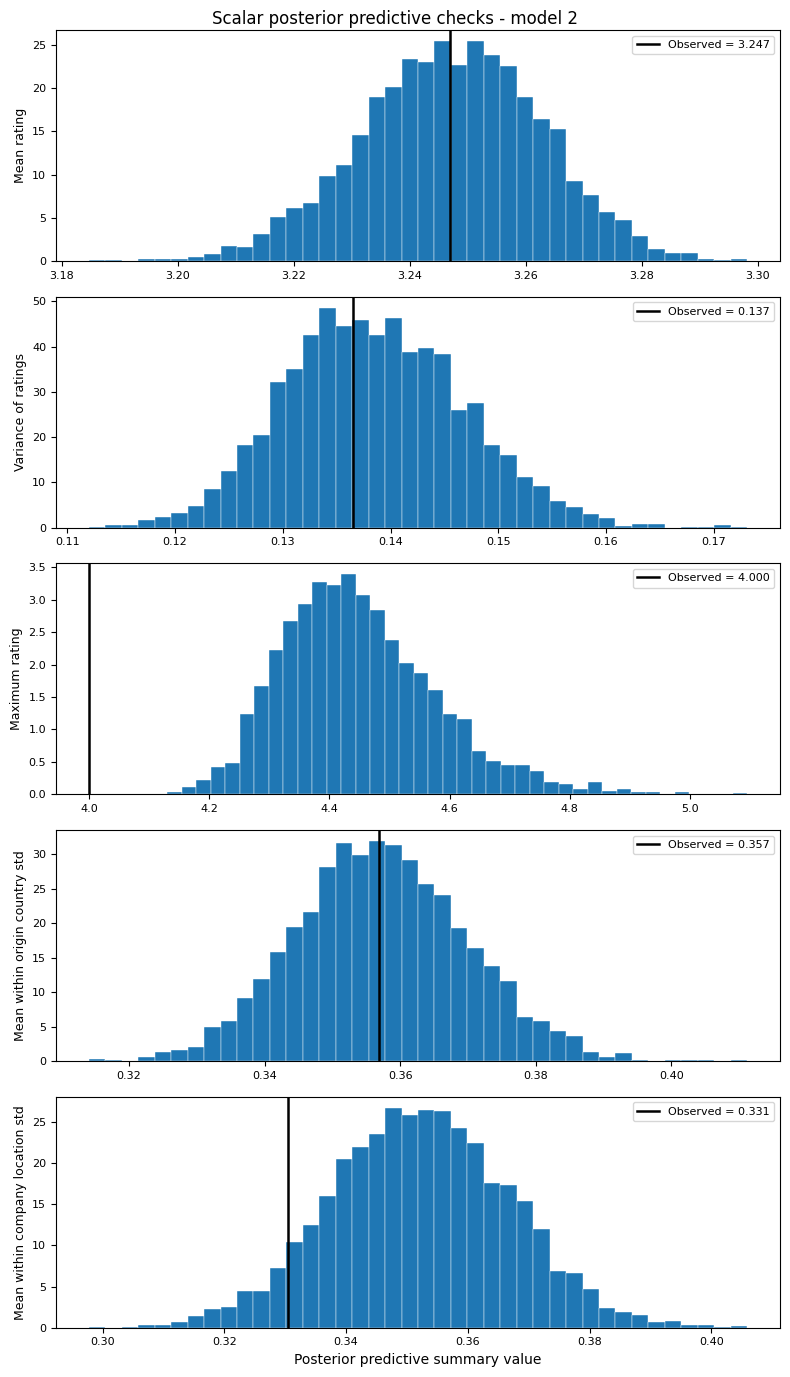

In [ ]:
obs    = df['Rating'].values
y_rep  = rating_pred_post3  

obs_mean         = obs.mean()
obs_var          = obs.var()
obs_min          = obs.min()
obs_max          = obs.max()
obs_fraction_low = np.mean(obs <= 3.0) 

rep_mean         = y_rep.mean(axis=1)
rep_var          = y_rep.var(axis=1)
rep_min          = y_rep.min(axis=1)
rep_max          = y_rep.max(axis=1)
rep_fraction_low = np.mean(y_rep <= 3.0, axis=1)

df_reset3 = df.reset_index(drop=True)
J_sorted3 = len(results3)

country_sds_rep = np.zeros((y_rep.shape[0], J_sorted3))
country_sds_obs = np.zeros(J_sorted3)

for i, country_name in enumerate(results3['country']):
    obs_indices = df_reset3[
        df_reset3['Country of Bean Origin'] == country_name
    ].index.values
    if len(obs_indices) > 1:
        country_sds_rep[:, i] = y_rep[:, obs_indices].std(axis=1)
        country_sds_obs[i]    = obs[obs_indices].std()

mean_country_sd_rep = country_sds_rep.mean(axis=1)
mean_country_sd_obs = country_sds_obs.mean()

location_names = df['Company Location'].unique()
J_loc3 = len(location_names)

loc_sds_rep = np.zeros((y_rep.shape[0], J_loc3))
loc_sds_obs = np.zeros(J_loc3)

for i, loc_name in enumerate(location_names):
    obs_indices = df_reset3[df_reset3['Company Location'] == loc_name].index.values
    if len(obs_indices) > 1:
        loc_sds_rep[:, i] = y_rep[:, obs_indices].std(axis=1)
        loc_sds_obs[i]    = obs[obs_indices].std()

mean_loc_sd_rep = loc_sds_rep.mean(axis=1)
mean_loc_sd_obs = loc_sds_obs[~np.isnan(loc_sds_obs)].mean()


fig, axes = plt.subplots(5, 1, figsize=(8, 14))

checks = [
    (rep_mean,            obs_mean,            'Mean rating'),
    (rep_var,             obs_var,             'Variance of ratings'),
    (rep_max,             obs_max,             'Maximum rating'),
    (mean_country_sd_rep, mean_country_sd_obs, 'Mean within origin country std'),
    (mean_loc_sd_rep,     mean_loc_sd_obs,     'Mean within company location std')
]

for ax, (rep_stat, obs_stat, ylabel) in zip(axes, checks):
    ax.hist(rep_stat, bins=40, density=True, edgecolor='white', linewidth=0.3)
    ax.axvline(obs_stat, linewidth=1.8, color='k',
               label=f'Observed = {obs_stat:.3f}')
    p_val = np.mean(rep_stat >= obs_stat)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Posterior predictive summary value', fontsize=10)
plt.suptitle('Scalar posterior predictive checks - model 2',
             fontsize=12)
plt.tight_layout()
plt.show()


The model reproduces the overall mean and variance of ratings well, with both observed values falling near the center of their respective posterior predictive distributions. The maximum rating check reveals a systematic limitation, as the model consistently predicts maximum ratings around 4.4 - 4.6, while the observed maximum is exactly 4.0, suggesting the Normal likelihood assigns probability to ratings above the true scale of 4.0 due to the absence of an explicit upper bound constraint in the model.

## Model comapirson

Both models were compared using two information criteria: WAIC 
(Widely Applicable Information Criterion) and PSIS-LOO 
(Pareto-Smoothed Importance Sampling Leave-One-Out Cross-Validation), 
computed via ArviZ from the log-likelihood values stored in the 
generated quantities block of each model.

### WAIC

         rank   elpd_waic     p_waic  elpd_diff    weight         se  \
Model 2     0 -431.910082  23.530980   0.000000  0.899234  19.831465   
Model 1     1 -447.904314  18.693625  15.994232  0.100766  19.878087   

              dse  warning scale  
Model 2  0.000000    False   log  
Model 1  6.616717    False   log  


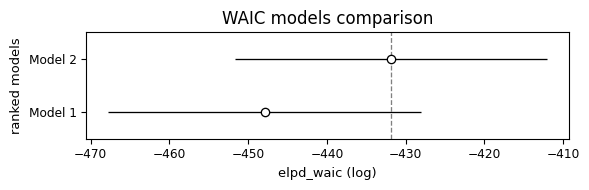

In [ ]:
comp_dict = {
    "Model 1": fit1,
    "Model 2": fit3
}
comp_waic = az.compare(comp_dict, ic="waic")
print(comp_waic)

az.plot_compare(comp_waic)
plt.title("WAIC models comparison")
plt.tight_layout()
plt.show()

Model 2  achieves higher expected log predictive density under WAIC (elpd_waic = -431.9) than Model 1 (elpd_waic = -447.9), with a difference of 16. No warnings were issued for either model. The standard error of the difference (dse = 6.62) yields a ratio of elpd_diff/dse ≈ 2.42, indicating that the difference is statistically meaningful and not attributable to sampling noise. While the confidence intervals in the comparison plot visually overlap, this reflects uncertainty in each model's absolute elpd estimate rather than the uncertainty in their difference, the latter is captured by dse and supports an advantage for Model 2.

### PSIS - LOO

         rank    elpd_loo      p_loo  elpd_diff    weight         se  \
Model 2     0 -431.993316  23.614214   0.000000  0.898675  19.834011   
Model 1     1 -447.968818  18.758129  15.975502  0.101325  19.880349   

              dse  warning scale  
Model 2  0.000000    False   log  
Model 1  6.617322    False   log  


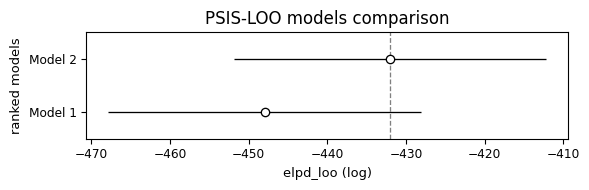

In [ ]:
comp_loo = az.compare(comp_dict, ic="loo")
print(comp_loo)

az.plot_compare(comp_loo)
plt.title("PSIS-LOO models comparison")
plt.tight_layout()
plt.show()

The PSIS-LOO results are consistent with WAIC. Model 2 achieves elpd_loo = -432.0 versus Model 1's - 448.0, a difference of 15.98 with dse = 6.62. No Pareto k warnings were issued, indicating that the importance sampling approximation is reliable for all observations in both models and that neither model is driven by a small number of highly influential points.
The ratio elpd_diff/dse ≈ 2.41 again exceeds 2, confirming Model 2 as the preferred model under PSIS-LOO. The near-identical results across both criteria (WAIC and LOO differ by less than 0.1 points) indicate that no outlier observations are distorting the comparison.

### Summary

Both criteria select Model 2 as the better predictive model and the difference is statistically meaningful (elpd_diff/dse $\approx$ 2.4 > 2). Model 2 additional predictors, such as number of ingredients, presence of vanilla, cocoa percantage and review year, provide genuine predictive signal beyond country level effects. This improvement is expected, as 
models with more parameters generally capture more variation in the data.

Model 2 is preffered model when complete chocolate ingredient information is available. However Model 1 also performs well and in our opinion, the practical difference between them is minor. Model 1 remains good alternative, particularly when only geographical information about bean origin and manufacturer is known, as it achieves comparable predictive performance with lower complexity.

## Sources
[1] : [Statista. (2026). Chocolate Confectionery - Worldwide: Market Insights & Forecast. Statista Consumer Market Outlook](https://www.statista.com/outlook/cmo/food/confectionery-snacks/confectionery/chocolate-confectionery/worldwide/?srsltid=AfmBOorxi7XFaZWdLCVjMUYGtJAp6RNSvUAMPQz5kLmDYZJz0M03wTzj)

[2] : [HTF Market Intelligence. (2026). Global Fine or Flavor Cocoa Market: Size, Industry Analysis, Trends, and Forecast to 2033. HTF Market Report.](https://www.htfmarketintelligence.com/report/global-fine-or-flavor-cocoa-market)

[3] : [Grand View Research. (2026). Chocolate Market Size, Share & Trends Analysis Report by Product (Traditional, Artificial), by Distribution Channel, and Segment Forecasts 2026 - 2033. Grand View Research.](https://www.grandviewresearch.com/industry-analysis/chocolate-market)

[4] : [Fanning, E., Eyres, G., Frew, R., & Kebede, B. (2023). Linking cocoa quality attributes to its origin using geographical indications. Food Control, 151, 109825.](https://www.sciencedirect.com/science/article/pii/S0956713523002256)